In [1]:
from starccato_flow.localisation.detector_network import DetectorNetwork
from starccato_flow.localisation.ccsn import CCSN

In [2]:
# Reload the module to get the updated transformation
import importlib
import starccato_flow.localisation.ccsn
importlib.reload(starccato_flow.localisation.ccsn)
from starccato_flow.localisation.ccsn import CCSN

# Load supernova locations with proper galactic-to-equatorial transformation
ccsn = CCSN(locations_file='../../exploded_supernovae_t100_sf5.csv')

✓ Loaded 1934076 supernova locations from ../../exploded_supernovae_t100_sf5.csv


In [ ]:
ccsn.plot_galactic_distribution(
    fname_3d='plots/galactic_supernovae_3d.png',
    fname_xy='plots/galactic_supernovae_xy.png',
    fname_xz='plots/galactic_supernovae_xz.png',
    background='black',
    font_family='sans-serif',
    font_name='Avenir',
    show=False,
    dpi=150,
)

Number of supernovae: 1934076
RA range: [-180.00°, 180.00°]
Dec range: [-88.27°, 86.85°]


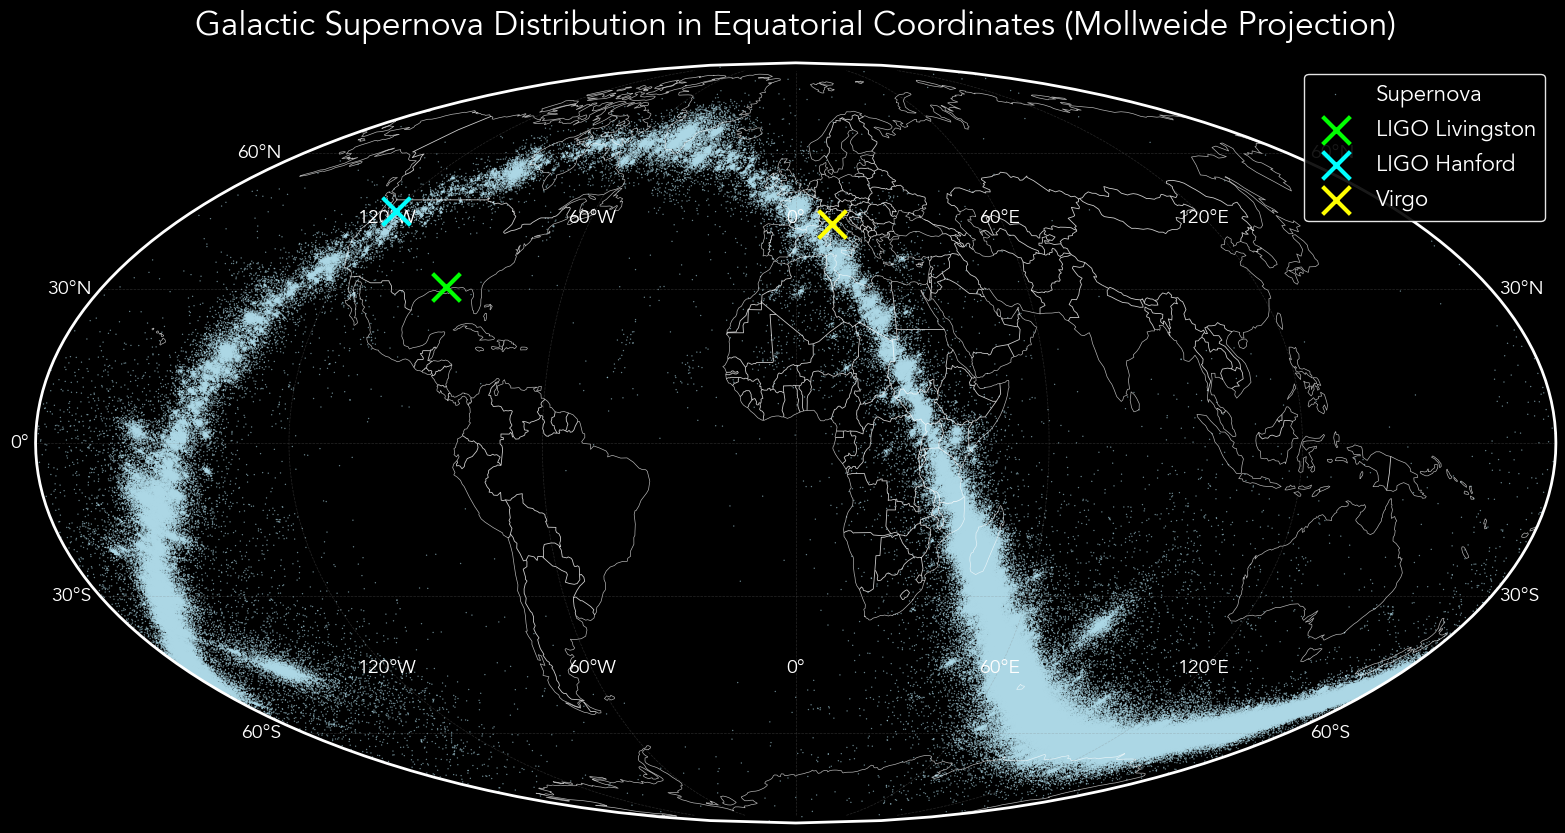


Supernovae shown in light blue
Detector network locations shown as colored crosses:
  • LIGO Livingston: LIME
  • LIGO Hanford: CYAN
  • Virgo: YELLOW

Map style: dark mode with country/coastline outlines only
The galactic plane should appear as a tilted band across this plot


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Dark mode style
plt.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18

# Extract RA and Dec from the CCSN object (already transformed)
ra = ccsn.ra  # radians
dec = ccsn.dec  # radians

# Convert to degrees for plotting/summary
ra_deg = np.degrees(ra)
dec_deg = np.degrees(dec)

print(f"Number of supernovae: {len(ra)}")
print(f"RA range: [{ra_deg.min():.2f}°, {ra_deg.max():.2f}°]")
print(f"Dec range: [{dec_deg.min():.2f}°, {dec_deg.max():.2f}°]")

# Detector locations (lon/lat in degrees)
detector_locs = {
    'LIGO Livingston': {'lon': -90.769, 'lat': 30.495, 'color': 'lime'},
    'LIGO Hanford': {'lon': -119.408, 'lat': 46.455, 'color': 'cyan'},
    'Virgo': {'lon': 10.504, 'lat': 43.631, 'color': 'yellow'}
}

# Create Mollweide map (dark mode)
fig = plt.figure(figsize=(16, 10), facecolor='black')
ax = fig.add_subplot(111, projection=ccrs.Mollweide(), facecolor='black')

# Country outlines only (no filled Earth map)
countries = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='110m',
    facecolor='none'
)
ax.add_feature(countries, edgecolor='white', linewidth=0.6, alpha=0.8)
ax.coastlines(color='white', linewidth=0.5, alpha=0.7)

# Wrap RA to [-pi, pi], then convert to degrees
ra_plot = np.where(ra > np.pi, ra - 2 * np.pi, ra)
ra_deg_plot = np.degrees(ra_plot)
dec_deg_plot = np.degrees(dec)

# Supernovae
ax.scatter(
    ra_deg_plot,
    dec_deg_plot,
    s=1,
    alpha=0.6,
    c='lightblue',
    edgecolors='none',
    label='Supernova',
    transform=ccrs.PlateCarree(),
)

# Detectors
for detector_name, coords in detector_locs.items():
    ax.scatter(
        coords['lon'],
        coords['lat'],
        s=400,
        c=coords['color'],
        marker='x',
        linewidths=3,
        label=detector_name,
        zorder=10,
        transform=ccrs.PlateCarree(),
    )

# Title
ax.set_title(
    'Galactic Supernova Distribution in Equatorial Coordinates (Mollweide Projection)',
    color='white',
    fontsize=24,
    pad=20,
    fontweight='bold',
)

# White ticks
ax.tick_params(colors='white', labelsize=18, width=3, length=10)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_color('white')
ax.spines['geo'].set_edgecolor('white')
ax.spines['geo'].set_linewidth(2)

# Grid with readable labels
gl = ax.gridlines(color='gray', alpha=0.3, linestyle='--', linewidth=0.5, draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'color': 'white', 'size': 14}
gl.ylabel_style = {'color': 'white', 'size': 14}

# Legend
ax.legend(
    loc='upper right',
    fontsize=16,
    facecolor='black',
    edgecolor='white',
    labelcolor='white',
    framealpha=0.9,
)

plt.tight_layout()
plt.savefig(
    'plots/galactic_supernovae_mollweide.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='black',
    edgecolor='none',
)
plt.show()

print("\nSupernovae shown in light blue")
print("Detector network locations shown as colored crosses:")
for detector_name, info in detector_locs.items():
    print(f"  • {detector_name}: {info['color'].upper()}")
print("\nMap style: dark mode with country/coastline outlines only")
print("The galactic plane should appear as a tilted band across this plot")

In [ ]:
# Create GIF: rotate Earth angle in 30° steps (0° to 330°)
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Styling
plt.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 16

# Base data from current CCSN object
ra = ccsn.ra
dec = ccsn.dec
gc_ra, gc_dec = ccsn.get_galactic_center_direction()
ra_plot = np.where(ra > np.pi, ra - 2 * np.pi, ra)
ra_deg_plot = np.degrees(ra_plot)
dec_deg_plot = np.degrees(dec)
gc_ra_plot = gc_ra if gc_ra <= np.pi else gc_ra - 2 * np.pi
gc_ra_deg = np.degrees(gc_ra_plot)
gc_dec_deg = np.degrees(gc_dec)

# Detector locations (stay fixed to Earth in this view)
detector_locs = {
    'LIGO Livingston': {'lon': -90.769, 'lat': 30.495, 'color': 'lime'},
    'LIGO Hanford': {'lon': -119.408, 'lat': 46.455, 'color': 'cyan'},
    'Virgo': {'lon': 10.504, 'lat': 43.631, 'color': 'yellow'}
}

# Output paths
plots_dir = Path('plots')
plots_dir.mkdir(parents=True, exist_ok=True)
frames_dir = plots_dir / 'gif_frames'
frames_dir.mkdir(parents=True, exist_ok=True)
gif_path = plots_dir / 'galactic_supernovae_rotation.gif'

# Rotation sequence
angles_deg = np.arange(0, 360, 30)
frame_paths = []

for angle in angles_deg:
    fig = plt.figure(figsize=(16, 10), facecolor='black')
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(), facecolor='black')

    # Country outlines + coastlines only
    countries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='110m',
        facecolor='none'
    )
    ax.add_feature(countries, edgecolor='white', linewidth=0.6, alpha=0.8)
    ax.coastlines(color='white', linewidth=0.5, alpha=0.7)

    # Rotate apparent sky by angle in RA, then wrap to [-180, 180]
    ra_rot = ((ra_deg_plot + angle + 180) % 360) - 180
    gc_ra_rot = ((gc_ra_deg + angle + 180) % 360) - 180

    # Plot supernovae
    ax.scatter(
        ra_rot,
        dec_deg_plot,
        s=1,
        alpha=0.6,
        c='lightblue',
        edgecolors='none',
        label='Supernova',
        transform=ccrs.PlateCarree(),
    )

    # Galactic center (black circle with white outline)
    ax.scatter(
        gc_ra_rot,
        gc_dec_deg,
        s=260,
        marker='o',
        c='black',
        edgecolors='white',
        linewidths=1.8,
        label='Galactic Center',
        zorder=11,
        transform=ccrs.PlateCarree(),
    )

    # Plot detectors
    for detector_name, coords in detector_locs.items():
        ax.scatter(
            coords['lon'],
            coords['lat'],
            s=400,
            c=coords['color'],
            marker='x',
            linewidths=3,
            label=detector_name,
            zorder=10,
            transform=ccrs.PlateCarree(),
        )

    ax.set_title(
        f'Simulated Galactic Supernova Distribution in Equatorial Coordinates — Earth Angle: {angle}°',
        color='white',
        fontsize=22,
        pad=16,
        fontweight='bold',
    )

    # Ticks/grid styling
    ax.tick_params(colors='white', labelsize=14, width=2, length=8)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_color('white')
    ax.spines['geo'].set_edgecolor('white')
    ax.spines['geo'].set_linewidth(1.8)

    gl = ax.gridlines(color='gray', alpha=0.3, linestyle='--', linewidth=0.5, draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'size': 12}
    gl.ylabel_style = {'color': 'white', 'size': 12}

    ax.legend(
        loc='upper right',
        fontsize=12,
        facecolor='black',
        edgecolor='white',
        labelcolor='white',
        framealpha=0.9,
    )

    frame_file = frames_dir / f'frame_{int(angle):03d}.png'
    fig.savefig(frame_file, dpi=120, bbox_inches='tight', facecolor='black', edgecolor='none')
    plt.close(fig)
    frame_paths.append(frame_file)

# Build GIF
images = [Image.open(fp) for fp in frame_paths]
images[0].save(
    gif_path,
    save_all=True,
    append_images=images[1:],
    duration=650,  # ms per frame
    loop=0,
)
for img in images:
    img.close()
s
print(f'✓ Saved GIF: {gif_path}')
print(f'✓ Frames: {len(frame_paths)} ({list(angles_deg)})')

✓ Saved GIF: plots/galactic_supernovae_rotation.gif
✓ Frames: 12 ([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330])


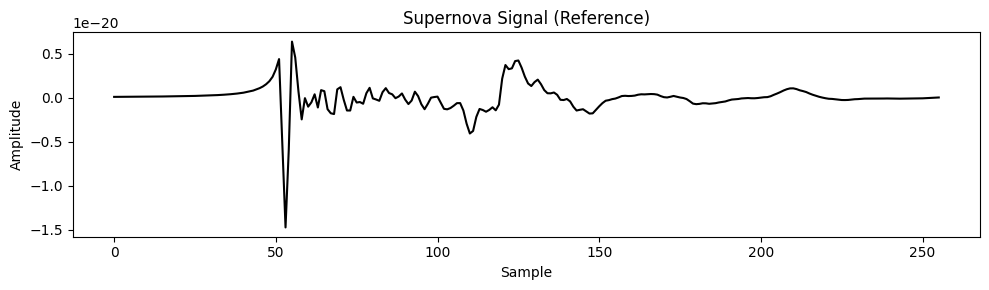

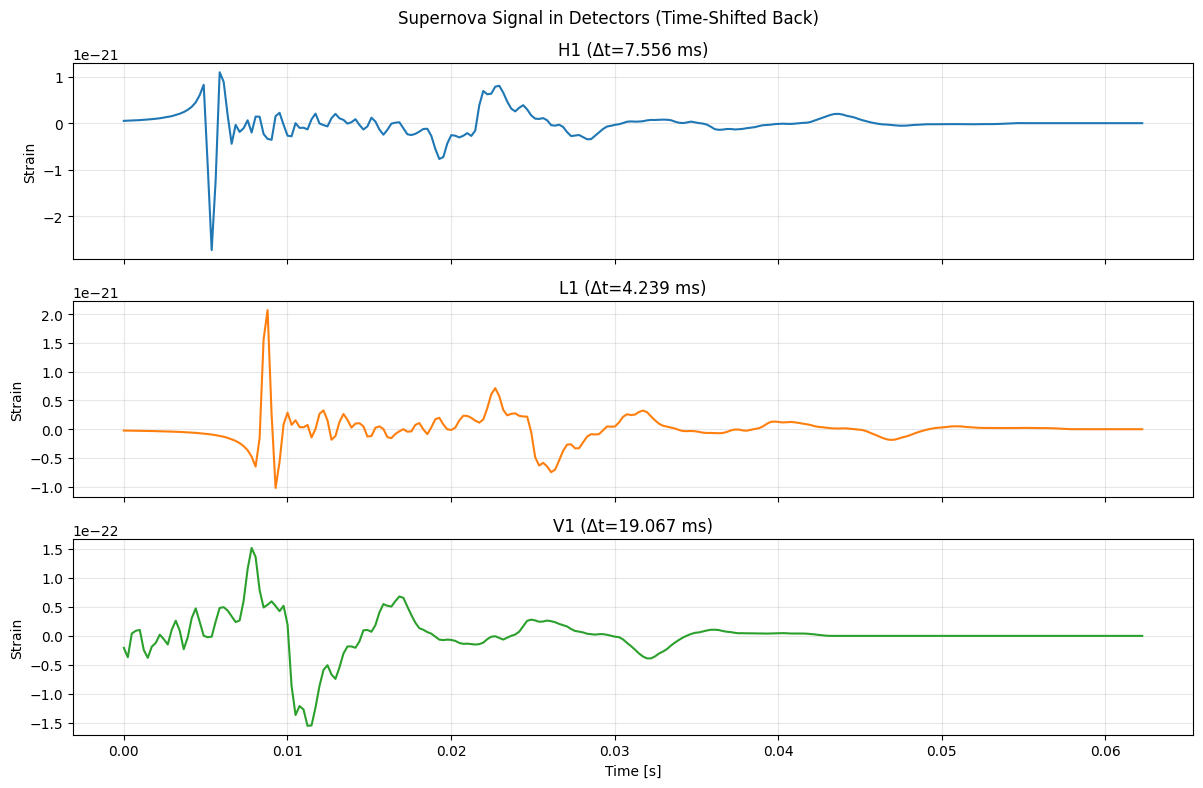

In [34]:
import bilby.gw.detector as det
import numpy as np
from matplotlib import pyplot as plt
from starccato_flow.data.ccsn_data import CCSNData
from starccato_flow.utils.defaults import TEN_KPC

# --------------------------
# Load CCSN waveform (reference signal at 10 kpc)
# --------------------------
ccsn_data = CCSNData()
sample_signal = ccsn_data.signals.T[901] / TEN_KPC  # waveform at 10 kpc

# Plot original reference signal
plt.figure(figsize=(10, 3))
plt.plot(sample_signal, color='black')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Supernova Signal (Reference)')
plt.tight_layout()
plt.show()

# --------------------------
# Source parameters
# --------------------------
ra = 10      # degrees
dec = -90     # degrees
psi = 0      # polarization angle
gps = 1457654242  # GPS time of the event

# Distance scaling
d0 = 10.0   # kpc (reference distance)
d = 10.0    # target distance
scale = d0 / d

# --------------------------
# Interferometers
# --------------------------
ifos = [
    det.get_empty_interferometer('H1'),
    det.get_empty_interferometer('L1'),
    det.get_empty_interferometer('V1')
]

# --------------------------
# Time array
# --------------------------
fs = 4096.0  # Hz sample rate
t = np.arange(len(sample_signal)) / fs  # seconds

# --------------------------
# Compute detector strains (shifted back by dt)
# --------------------------
strains = []
titles = []
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ifo, color in zip(ifos, colors):
    # Antenna response
    fp = ifo.antenna_response(ra, dec, gps, psi, mode='plus')

    # Time delay from geocenter to detector
    dt = ifo.time_delay_from_geocenter(ra, dec, gps)

    # Shift waveform backward: detector sees it later than geocenter
    shifted_signal = np.interp(t + dt, t, sample_signal, left=0, right=0)

    # Apply antenna pattern and distance scaling
    h_det = scale * fp * shifted_signal

    strains.append(h_det)
    titles.append(f'{ifo.name} (Δt={dt*1e3:.3f} ms)')

# --------------------------
# Plot stacked detector strains
# --------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, h, title, color in zip(axes, strains, titles, colors):
    ax.plot(t, h, color=color)
    ax.set_ylabel('Strain')
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[2].set_xlabel('Time [s]')
fig.suptitle('Supernova Signal in Detectors (Time-Shifted Back)', y=0.98)
plt.tight_layout()
plt.show()